In [3]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

In [4]:
def create_Hamiltonian(J_12, J_23, J_31):
    H = np.zeros((3,3), dtype=complex)

    H[0, 1] = J_12
    H[1, 0] = np.conjugate(J_12)

    H[1, 2] = J_23
    H[2, 1] = np.conjugate(J_23)

    H[2, 0] = J_31
    H[0, 2] = np.conjugate(J_31)

    return H



In [5]:
def simultaneous_diagonalization(H, T, tol=1e-10):
    if not np.allclose(H @ T, T @ H, atol=tol):
        raise ValueError("H and T do not commute.")

    # Diagonalize H
    evals_H, V = np.linalg.eigh(H)

    n = len(evals_H)
    energies = np.zeros(n)
    evals_T = np.zeros(n, dtype=complex)
    V_out = np.zeros_like(V, dtype=complex)

    used = np.zeros(n, dtype=bool)
    col = 0

    for i in range(n):
        if used[i]:
            continue

        block = np.where(np.abs(evals_H - evals_H[i]) < tol)[0]
        used[block] = True
        k = len(block)

        V_block = V[:, block]
        T_block = V_block.conj().T @ T @ V_block

        evals_block, W = np.linalg.eig(T_block)

        V_out[:, col:col+k] = V_block @ W
        evals_T[col:col+k] = evals_block

        # ✅ Preserve the correct energies
        energies[col:col+k] = evals_H[block]

        col += k

    return energies, evals_T, V_out


In [148]:
def analyze_H(H, phi=0, print_logs=False):
    '''
    phi assumes symmetric gauge
    '''
    
    num_qubits = H.shape[0]

    R = np.zeros(H.shape, dtype=complex)

    for i in range(num_qubits):
        R[i, (i+1)%num_qubits] = -H[i, (i+1)%num_qubits]
        # R[i, (i+1)%num_qubits] = -np.exp(-1j * phi/num_qubits)
        # R[i, (i+1)%num_qubits] = -1

    if print_logs:
        print("Hamiltonian H:")
        print(H.real)
        print("\nTranslation Operator R:")
        print(R)


    # Simultaneous diagonalization
    try:
        evals_H, evals_R, eigenvectors = simultaneous_diagonalization(H, R)

        
    except ValueError as e:
        print("Error during simultaneous diagonalization:", e)
        
        energy_eigenvalues, eigenvectors = np.linalg.eigh(H)
        current_eigenvalues = None

    else:
        current_eigenvalues = np.mod(np.angle(evals_R) + phi + np.pi, 2*np.pi) - np.pi  # quasimomentum
        energy_eigenvalues = evals_H.real  # energy



    ground_state = eigenvectors[:, np.argmin(energy_eigenvalues)]

    N = len(ground_state)

    coherence_matrices = []
    measurement = []
    for i in range(N):
        coherence_matrix = np.zeros((N,N), dtype=complex)
        coherence_matrix[i, (i+1)%N] = H[i, (i+1)%N]
        coherence_matrices.append(coherence_matrix)
        measurement.append(np.conjugate(ground_state) @ coherence_matrix @ ground_state)
    
    return current_eigenvalues, energy_eigenvalues, eigenvectors, ground_state, coherence_matrices, measurement

In [7]:
H0 = create_Hamiltonian(-1, -1, -1)


In [8]:
current_eigenvalues, energy_eigenvalues, eigenvectors, ground_state, coherence_matrices, measurement = analyze_H(H0)
print("Current Eigenvalues:", current_eigenvalues)
print("Energy Eigenvalues:", energy_eigenvalues)
print("Eigenvectors:", eigenvectors)
print("Ground State:", ground_state)
print("Coherence Matrices:", coherence_matrices)
print("Measurements:", measurement)


Current Eigenvalues: [ 0.         2.0943951 -2.0943951]
Energy Eigenvalues: [-2.  1.  1.]
Eigenvectors: [[-0.57735027+0.j          0.29875496+0.49404333j  0.29875496-0.49404333j]
 [-0.57735027+0.j         -0.57723155+0.01170772j -0.57723155-0.01170772j]
 [-0.57735027+0.j          0.27847659-0.50575105j  0.27847659+0.50575105j]]
Ground State: [-0.57735027+0.j -0.57735027+0.j -0.57735027+0.j]
Coherence Matrices: [array([[ 0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j]]), array([[ 0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j]]), array([[ 0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j],
       [-1.+0.j,  0.+0.j,  0.+0.j]])]
Measurements: [(-0.3333333333333332+0j), (-0.3333333333333332+0j), (-0.3333333333333333+0j)]


In [9]:
phis = np.linspace(0, 2*np.pi, 101)

measurements_1 = []
measurements_2 = []

for i in range(len(phis)):
    phi = phis[i]
    J_12 = -1 * np.exp(1j * phi / 3)
    J_23 = -1 * np.exp(1j * phi / 3)
    J_31 = -1 * np.exp(1j * phi / 3)

    H_1 = create_Hamiltonian(-1 * np.exp(1j * phi), -1, -1)
    H_2 = create_Hamiltonian(*[-1 * np.exp(1j * phi / 3)]*3)
    
    result_1 = analyze_H(H_1)
    result_2 = analyze_H(H_2)

    measurements_1.append(result_1[5])
    measurements_2.append(result_2[5])

measurements_1 = np.array(measurements_1)
measurements_2 = np.array(measurements_2)

ValueError: H and T do not commute.

In [ ]:
print(measurements_1.shape)

(101, 3)


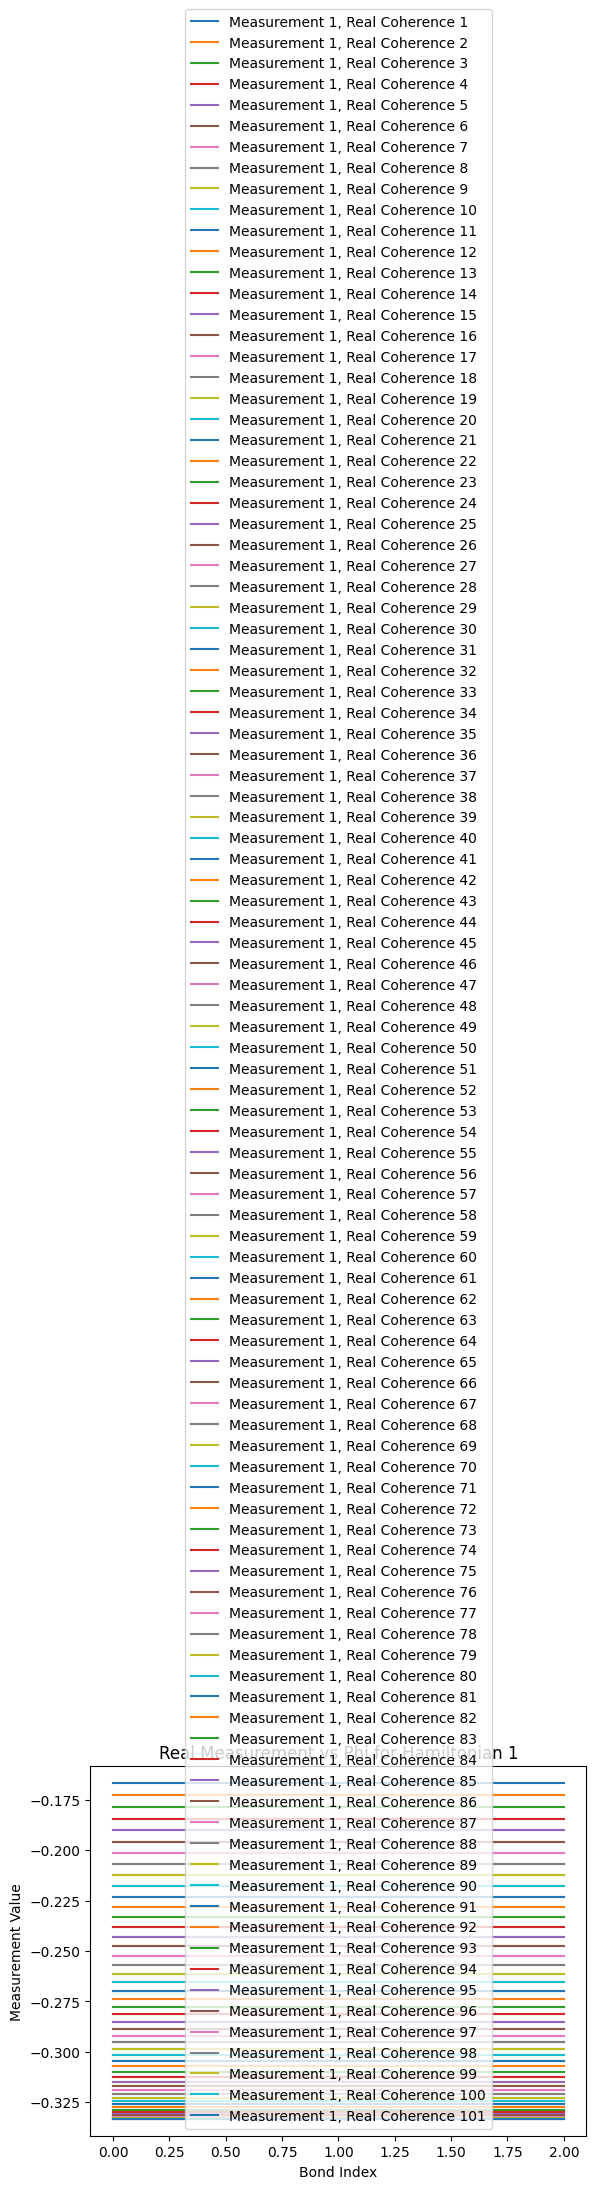

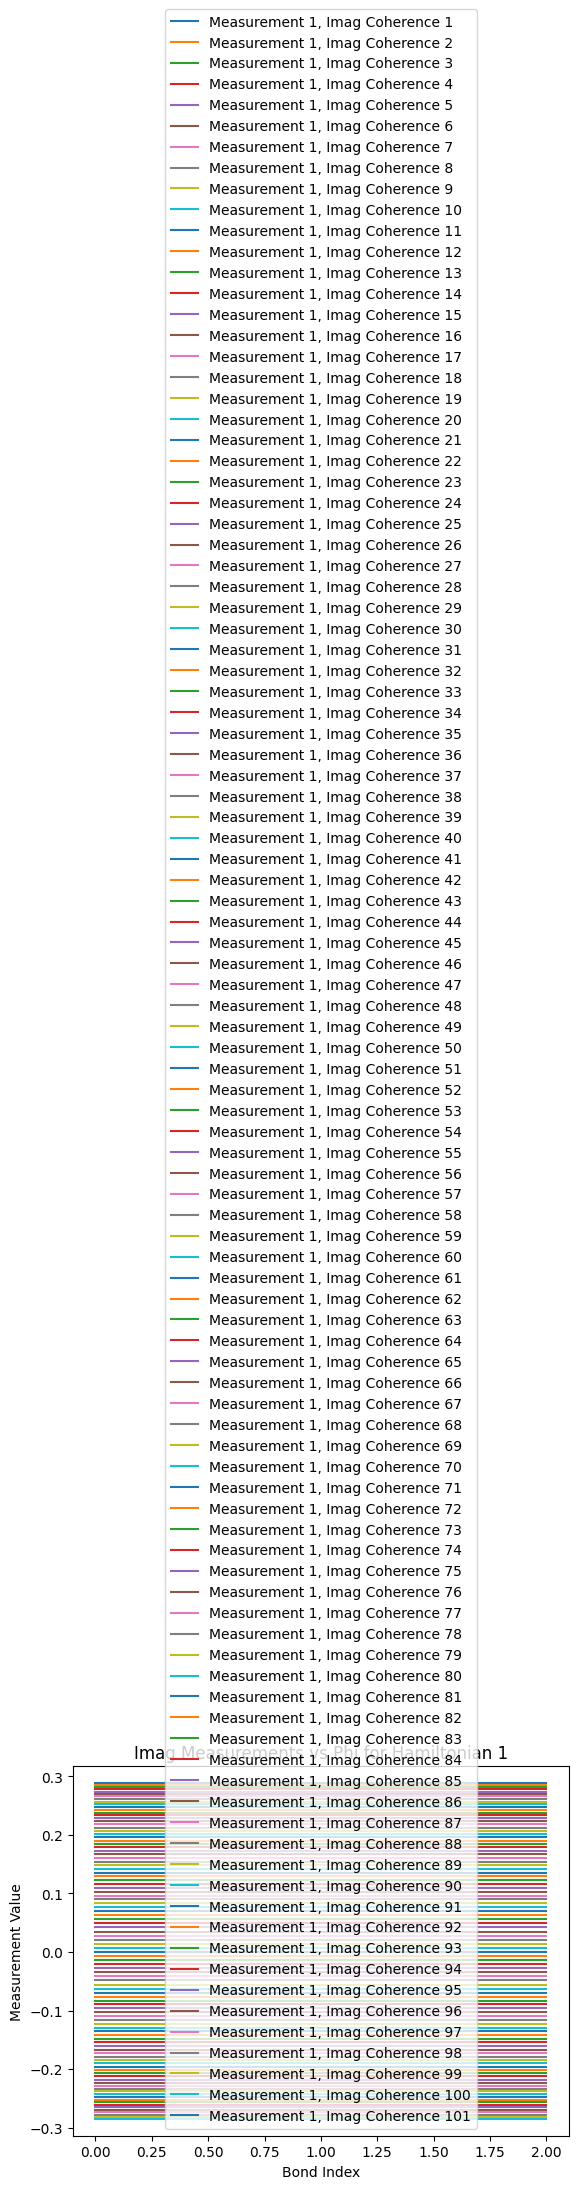

In [ ]:
for i in range(len(phis)):
    plt.plot(measurements_1[i,:].real, label=f'Measurement 1, Real Coherence {i+1}')

plt.xlabel('Bond Index')
plt.ylabel('Measurement Value')
plt.title('Real Measurement vs Phi for Hamiltonian 1')

plt.legend()
plt.show()


for i in range(len(phis)):
    plt.plot(measurements_1[i,:].imag, label=f'Measurement 1, Imag Coherence {i+1}')

plt.xlabel('Bond Index')
plt.ylabel('Measurement Value')
plt.title('Imag Measurements vs Phi for Hamiltonian 1')

plt.legend()
plt.show()



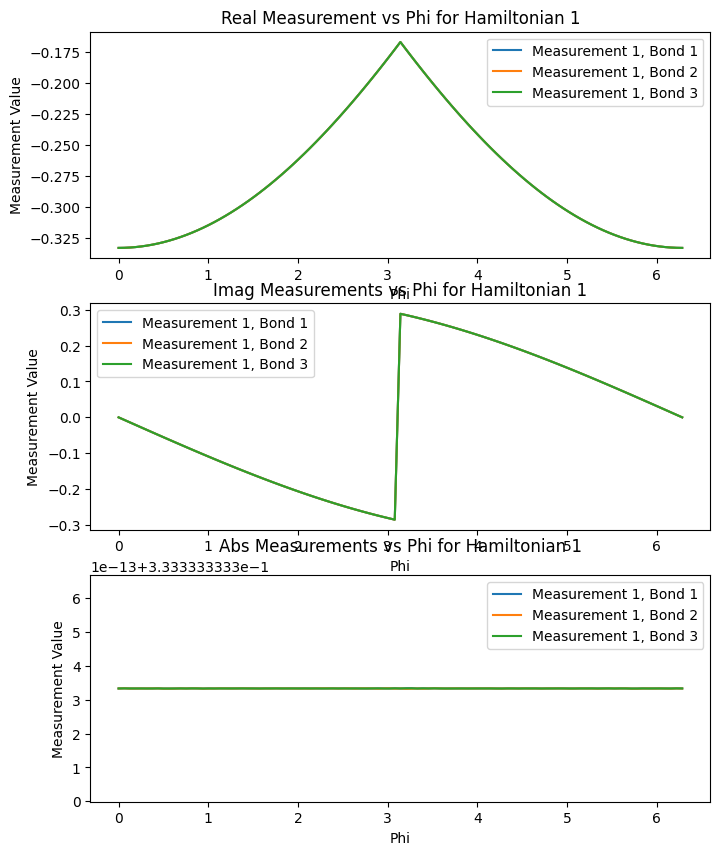

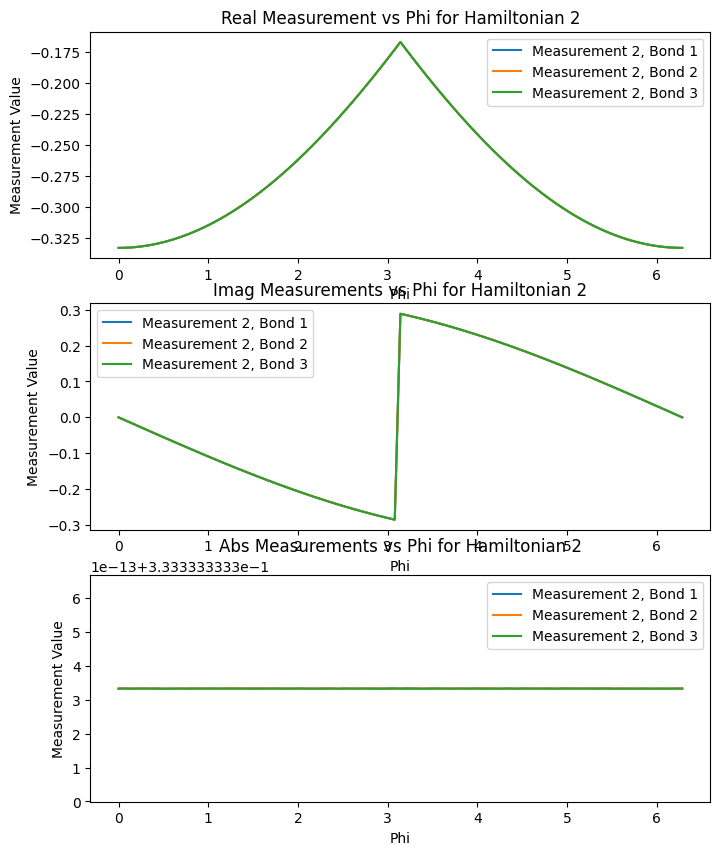

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i in range(3):
    axes[0].plot(phis, measurements_1[:,i].real, label=f'Measurement 1, Bond {i+1}')
    axes[1].plot(phis, measurements_1[:,i].imag, label=f'Measurement 1, Bond {i+1}')
    axes[2].plot(phis, np.abs(measurements_1[:,i]), label=f'Measurement 1, Bond {i+1}')

axes[0].set_xlabel('Phi')
axes[0].set_ylabel('Measurement Value')
axes[0].set_title('Real Measurement vs Phi for Hamiltonian 1')
axes[0].legend()

axes[1].set_xlabel('Phi')
axes[1].set_ylabel('Measurement Value')
axes[1].set_title('Imag Measurements vs Phi for Hamiltonian 1')
axes[1].legend()

axes[2].set_xlabel('Phi')
axes[2].set_ylabel('Measurement Value')
axes[2].set_title('Abs Measurements vs Phi for Hamiltonian 1')
axes[2].legend()

plt.show()


fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i in range(3):
    axes[0].plot(phis, measurements_2[:,i].real, label=f'Measurement 2, Bond {i+1}')
    axes[1].plot(phis, measurements_2[:,i].imag, label=f'Measurement 2, Bond {i+1}')
    axes[2].plot(phis, np.abs(measurements_2[:,i]), label=f'Measurement 2, Bond {i+1}')

axes[0].set_xlabel('Phi')
axes[0].set_ylabel('Measurement Value')
axes[0].set_title('Real Measurement vs Phi for Hamiltonian 2')
axes[0].legend()

axes[1].set_xlabel('Phi')
axes[1].set_ylabel('Measurement Value')
axes[1].set_title('Imag Measurements vs Phi for Hamiltonian 2')
axes[1].legend()

axes[2].set_xlabel('Phi')
axes[2].set_ylabel('Measurement Value')
axes[2].set_title('Abs Measurements vs Phi for Hamiltonian 2')
axes[2].legend()

plt.show()





### 2. N Qubit Loop

In [10]:
def create_Hamiltonian_N(J):

    N = len(J)

    H = np.zeros((N,N), dtype=complex)

    for i in range(N):
        H[i, (i+1)%N] = J[i]
        H[(i+1)%N, i] = np.conjugate(J[i])

    return H



[[0.+0.j 1.-0.j 1.+0.j]
 [1.+0.j 0.+0.j 1.-0.j]
 [1.-0.j 1.+0.j 0.+0.j]]
Eigenvalues at phi=0:
 [-2.0, 1.0, 1.0]


[[0. +0.j        0.5+0.8660254j 0.5-0.8660254j]
 [0.5-0.8660254j 0. +0.j        0.5+0.8660254j]
 [0.5+0.8660254j 0.5-0.8660254j 0. +0.j       ]]
Eigenvalues at phi=pi:
 [-1.0, -1.0, 2.0]


[[0.       +0.j  0.8660254+0.5j 0.8660254-0.5j]
 [0.8660254-0.5j 0.       +0.j  0.8660254+0.5j]
 [0.8660254+0.5j 0.8660254-0.5j 0.       +0.j ]]
Eigenvalues at phi=pi/2:
 [-1.73, 0.0, 1.73]


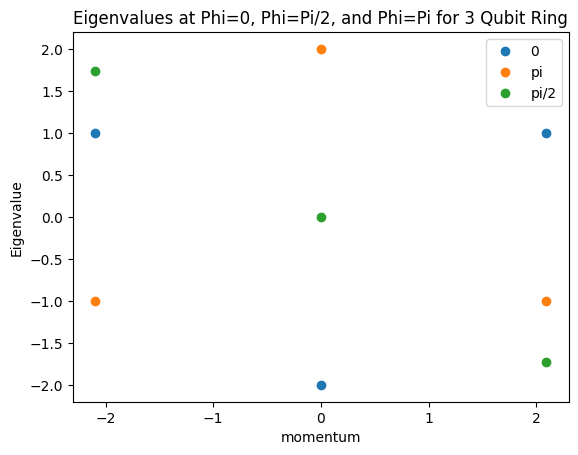

In [133]:
### pi eigenvalues

num_qubits = 3
H_0 = create_Hamiltonian_N([-1]*num_qubits)
result = analyze_H(H_0, 0)
current_eigenvalues = result[0]
energy_eigenvalues = result[1]
print("Eigenvalues at phi=0:\n", list(np.round(sorted(energy_eigenvalues.real),2)))


plt.plot(current_eigenvalues, energy_eigenvalues, marker='o', linestyle='None', label='0')

    
phi = np.pi
H_pi = create_Hamiltonian_N([-1 * np.exp(1j * phi / num_qubits)]*num_qubits)
# H_pi = create_Hamiltonian_N([-1,-1]+[1]*(num_qubits-2))
result = analyze_H(H_pi, phi)
current_eigenvalues = result[0]
energy_eigenvalues = result[1]
print("Eigenvalues at phi=pi:\n", list(np.round(sorted(energy_eigenvalues.real),2)))
plt.plot(current_eigenvalues, energy_eigenvalues, marker='o', linestyle='None', label='pi')



phi = np.pi/2
H_pi2 = create_Hamiltonian_N([-1 * np.exp(1j * phi / num_qubits)]*num_qubits)
result = analyze_H(H_pi2, phi)
current_eigenvalues = result[0]
energy_eigenvalues = result[1]
print("Eigenvalues at phi=pi/2:\n", list(np.round(sorted(energy_eigenvalues.real),2)))

plt.plot(current_eigenvalues, energy_eigenvalues, marker='o', linestyle='None', label='pi/2')

plt.xlabel('momentum')
plt.ylabel('Eigenvalue')

plt.title(f'Eigenvalues at Phi=0, Phi=Pi/2, and Phi=Pi for {num_qubits} Qubit Ring')
plt.legend()


In [210]:
num_qubits = 3


phis = np.linspace(0, 2*np.pi, 101)
J_s = [] 

measurements = []
ground_states = []

for i in range(len(phis)):
    phi = phis[i]

    J = np.array([-1 * np.exp(1j * phi / num_qubits)]*num_qubits)
    J = np.array([-1*np.exp(1j * phi)] + [-1]*(num_qubits-1))
    J_s.append(J)

    H = create_Hamiltonian_N(J)

    # print(H)
    
    result = analyze_H(H)

    current_eigenvalues, energy_eigenvalues, eigenvectors, ground_state, coherence_matrices, measurement = result
    print()
    print(phi)
    print(eigenvectors[:,0])
    print(np.outer(ground_state, np.conjugate(ground_state)))
    print()

    measurements.append(result[5])
    ground_states.append(result[3])

measurements = np.array(measurements)
measurements


0.0
[-0.57735027+0.j -0.57735027+0.j -0.57735027+0.j]
[[0.33333333+0.j 0.33333333+0.j 0.33333333+0.j]
 [0.33333333+0.j 0.33333333+0.j 0.33333333+0.j]
 [0.33333333+0.j 0.33333333+0.j 0.33333333+0.j]]


0.06283185307179587
[0.57735027+0.j         0.57684383-0.02417692j 0.57722365-0.01209111j]
[[0.33333333+0.00000000e+00j 0.33304094+1.39585512e-02j
  0.33326023+6.98080663e-03j]
 [0.33304094-1.39585512e-02j 0.33333333-6.70087006e-19j
  0.33326023-6.98080663e-03j]
 [0.33326023-6.98080663e-03j 0.33326023+6.98080663e-03j
  0.33333333+6.58131976e-20j]]


0.12566370614359174
[0.57735027+0.j         0.57532542-0.04831143j 0.57684383-0.02417692j]
[[0.33333333+0.00000000e+00j 0.33216429+2.78926144e-02j
  0.33304094+1.39585512e-02j]
 [0.33216429-2.78926144e-02j 0.33333333-1.57163844e-18j
  0.33304094-1.39585512e-02j]
 [0.33304094-1.39585512e-02j 0.33304094+1.39585512e-02j
  0.33333333-4.47122979e-19j]]


0.1884955592153876
[0.57735027+0.j         0.57279769-0.07236118j 0.576211  -0.03625212j]
[[0.

array([[-0.33333333+0.00000000e+00j, -0.33333333+0.00000000e+00j,
        -0.33333333+0.00000000e+00j],
       [-0.33326023-6.98080663e-03j, -0.33326023-6.98080663e-03j,
        -0.33326023-6.98080663e-03j],
       [-0.33304094-1.39585512e-02j, -0.33304094-1.39585512e-02j,
        -0.33304094-1.39585512e-02j],
       [-0.33267558-2.09301732e-02j, -0.33267558-2.09301732e-02j,
        -0.33267558-2.09301732e-02j],
       [-0.33216429-2.78926144e-02j, -0.33216429-2.78926144e-02j,
        -0.33216429-2.78926144e-02j],
       [-0.3315073 -3.48428211e-02j, -0.3315073 -3.48428211e-02j,
        -0.3315073 -3.48428211e-02j],
       [-0.3307049 -4.17777445e-02j, -0.3307049 -4.17777445e-02j,
        -0.3307049 -4.17777445e-02j],
       [-0.32975744-4.86943429e-02j, -0.32975744-4.86943429e-02j,
        -0.32975744-4.86943429e-02j],
       [-0.32866535-5.55895822e-02j, -0.32866535-5.55895822e-02j,
        -0.32866535-5.55895822e-02j],
       [-0.32742908-6.24604382e-02j, -0.32742908-6.24604382e-02j

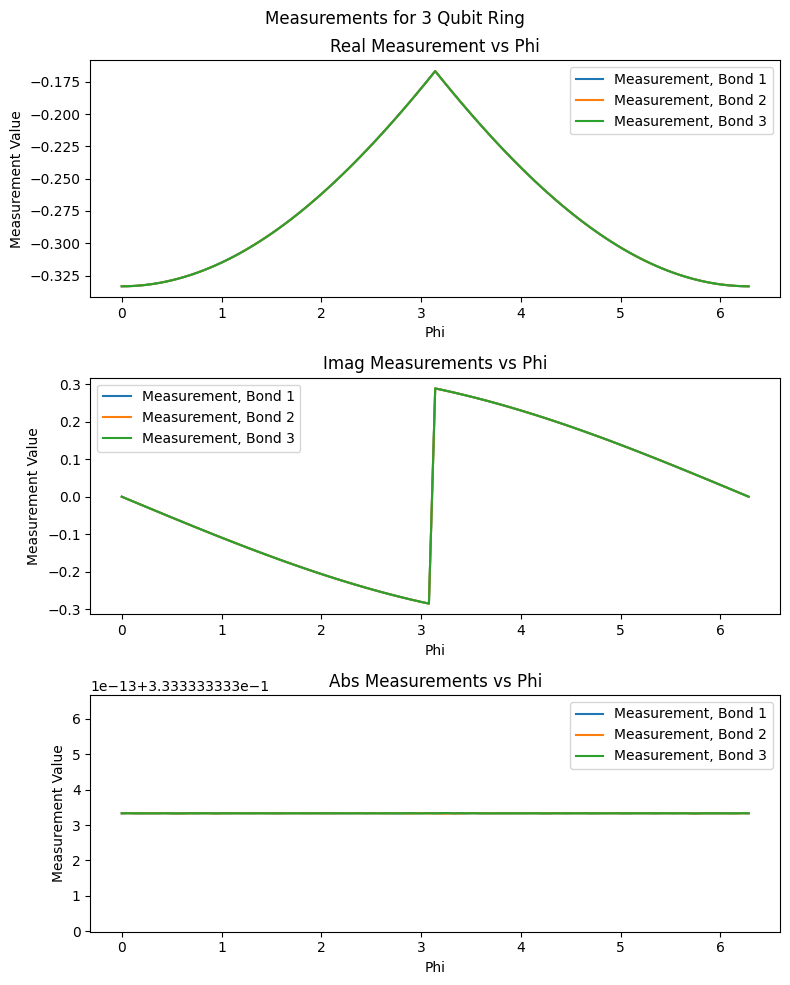

In [211]:

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i in range(num_qubits):
    axes[0].plot(phis, measurements[:,i].real, label=f'Measurement, Bond {i+1}')
    axes[1].plot(phis, measurements[:,i].imag, label=f'Measurement, Bond {i+1}')
    axes[2].plot(phis, np.abs(measurements[:,i]), label=f'Measurement, Bond {i+1}')

axes[0].set_xlabel('Phi')
axes[0].set_ylabel('Measurement Value')
axes[0].set_title('Real Measurement vs Phi')
axes[0].legend()

axes[1].set_xlabel('Phi')
axes[1].set_ylabel('Measurement Value')
axes[1].set_title('Imag Measurements vs Phi')
axes[1].legend()

axes[2].set_xlabel('Phi')
axes[2].set_ylabel('Measurement Value')
axes[2].set_title('Abs Measurements vs Phi')
axes[2].legend()

plt.suptitle(f'Measurements for {num_qubits} Qubit Ring')


plt.tight_layout()
plt.show()



In [141]:
measurements_analytic = np.zeros((len(phis), num_qubits), dtype=complex)

for i in range(len(phis)):
    phi = phis[i]
    for j in range(num_qubits):
        if 0 <= phi < np.pi:
            measurements_analytic[i,j] = -np.abs(J_s[i][j]) * np.exp(1j * phi/num_qubits)/num_qubits
        elif np.pi < phi <= 2*np.pi:
            measurements_analytic[i,j] = -np.abs(J_s[i][j]) * np.exp(-1j * (2*np.pi - phi)/num_qubits)/num_qubits
        else:
            measurements_analytic[i,j] = 0


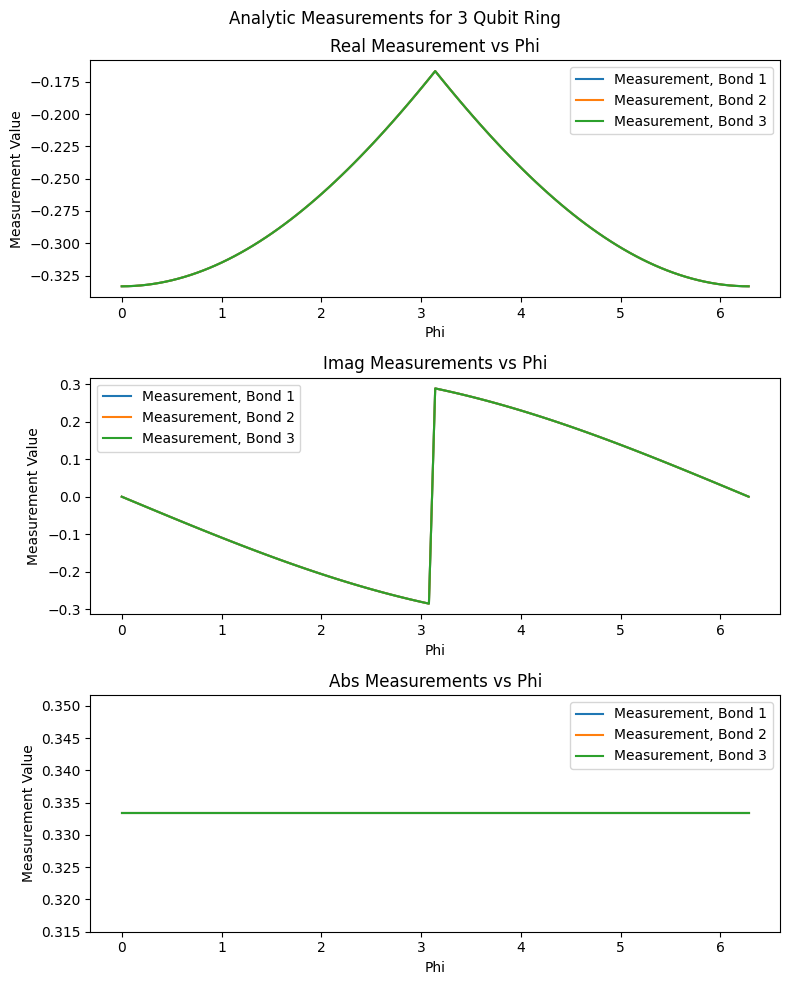

In [142]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i in range(num_qubits):
    axes[0].plot(phis, measurements_analytic[:,i].real, label=f'Measurement, Bond {i+1}')
    axes[1].plot(phis, measurements_analytic[:,i].imag, label=f'Measurement, Bond {i+1}')
    axes[2].plot(phis, np.abs(measurements_analytic[:,i]), label=f'Measurement, Bond {i+1}')

axes[0].set_xlabel('Phi')
axes[0].set_ylabel('Measurement Value')
axes[0].set_title('Real Measurement vs Phi')
axes[0].legend()

axes[1].set_xlabel('Phi')
axes[1].set_ylabel('Measurement Value')
axes[1].set_title('Imag Measurements vs Phi')
axes[1].legend()

axes[2].set_xlabel('Phi')
axes[2].set_ylabel('Measurement Value')
axes[2].set_title('Abs Measurements vs Phi')
axes[2].legend()

plt.suptitle(f'Analytic Measurements for {num_qubits} Qubit Ring')

plt.tight_layout()
plt.show()


In [212]:
a = np.array([2,1/np.sqrt(17)*(4+1j)])/np.sqrt(2)
np.outer(a, np.conjugate(a))

array([[2.       +0.00000000e+00j, 0.9701425-2.42535625e-01j],
       [0.9701425+2.42535625e-01j, 0.5      -4.51002060e-18j]])

In [213]:
print(ground_states[1])
print(np.outer(ground_states[1], np.conjugate(ground_states[1])))

[0.57735027+0.j         0.57684383-0.02417692j 0.57722365-0.01209111j]
[[0.33333333+0.00000000e+00j 0.33304094+1.39585512e-02j
  0.33326023+6.98080663e-03j]
 [0.33304094-1.39585512e-02j 0.33333333-6.70087006e-19j
  0.33326023-6.98080663e-03j]
 [0.33326023-6.98080663e-03j 0.33326023+6.98080663e-03j
  0.33333333+6.58131976e-20j]]


In [283]:
### compare numerical and analytic ground states

ground_states_analytic = []

for i in range(len(phis)):

    phi = phis[i]

    gauge_transformation = np.diag(np.zeros(num_qubits, dtype=complex))
    if phi <= np.pi:
        gauge_transformation[0,0] = 1
        gauge_transformation[1,1] = np.exp(-1j * 2*phi/num_qubits)
        gauge_transformation[2,2] = np.exp(-1j * phi/num_qubits)
    else:
        gauge_transformation[0,0] = 1
        gauge_transformation[1,1] = np.exp(1j * phi/num_qubits)
        gauge_transformation[2,2] = np.exp(1j - 2*phi/num_qubits)

    if phi > np.pi + 1:
        print(np.angle(gauge_transformation))
        print(phi)
        print(phi/num_qubits)

        print(gauge_transformation)
    
    rho_analytic = np.zeros((num_qubits, num_qubits), dtype=complex)


    for j in range(num_qubits):
        rho_analytic[j,j] = 1/num_qubits
        rho_analytic[j,(j+1)%num_qubits] = 1/num_qubits
        rho_analytic[(j+1)%num_qubits,j] = 1/num_qubits

    rho_analytic = gauge_transformation @ rho_analytic @ np.conjugate(gauge_transformation).T

    if phi > np.pi + 1:
        print(ground_states[i])
        print(gauge_transformation @ np.ones(num_qubits)/np.sqrt(num_qubits))
        print()
        print()
    # print(rho_analytic)
    rho = np.outer(ground_states[i], np.conjugate(ground_states[i]))
    # print(rho)

    if phi > np.pi + 1:
        print(rho_analytic.real)
        print(rho.real)

        break

    # print(np.allclose(rho, rho_analytic))

[[0.         0.         0.        ]
 [0.         1.38230077 0.        ]
 [0.         0.         1.        ]]
4.1469023027385274
1.3823007675795091
[[1.        +0.j         0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.18738131+0.98228725j 0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.03403969+0.05301368j]]
[0.57735027+0.j         0.08434108+0.57115665j 0.4370513 +0.37725256j]
[0.57735027+0.j         0.10818465+0.56712381j 0.01965283+0.03060746j]


[[0.33333333 0.06246044 0.01134656]
 [0.06246044 0.33333333 0.01948435]
 [0.01134656 0.01948435 0.00132305]]
[[0.33333333 0.04869434 0.25233169]
 [0.04869434 0.33333333 0.25233169]
 [0.25233169 0.25233169 0.33333333]]


In [278]:
print(np.angle(0.08434108+0.57115665j))
print(np.angle(0.05865746+0.57436281j))

phi/3

1.4241886631137246
1.4690230257401948


1.3823007675795091

### 2.2 Different J

In [157]:
num_qubits = 3


phis = np.linspace(0, 2*np.pi, 101)

J_s = []

measurements = []

for i in range(len(phis)):
    phi = phis[i]

    J = np.array([-1 * np.exp(1j * phi / num_qubits)]*num_qubits)
    J = np.array([-4*np.exp(1j*phi)] + [-1]*(num_qubits-1))

    H = create_Hamiltonian_N(J)
    
    result = analyze_H(H, print_logs=False)

    measurements.append(result[5])
    J_s.append(J)

measurements = np.array(measurements)

Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not commute.
Error during simultaneous diagonalization: H and T do not comm

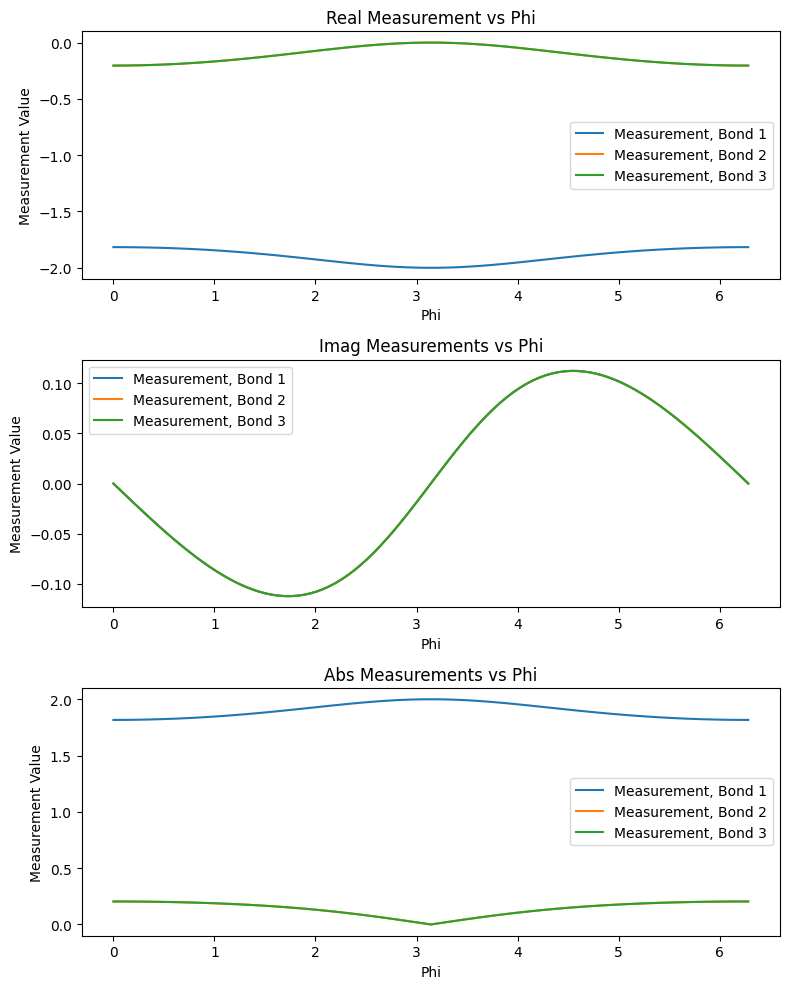

In [158]:

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i in range(num_qubits):
    axes[0].plot(phis, measurements[:,i].real, label=f'Measurement, Bond {i+1}')
    axes[1].plot(phis, measurements[:,i].imag, label=f'Measurement, Bond {i+1}')
    axes[2].plot(phis, np.abs(measurements[:,i]), label=f'Measurement, Bond {i+1}')

axes[0].set_xlabel('Phi')
axes[0].set_ylabel('Measurement Value')
axes[0].set_title('Real Measurement vs Phi')
axes[0].legend()

axes[1].set_xlabel('Phi')
axes[1].set_ylabel('Measurement Value')
axes[1].set_title('Imag Measurements vs Phi')
axes[1].legend()

axes[2].set_xlabel('Phi')
axes[2].set_ylabel('Measurement Value')
axes[2].set_title('Abs Measurements vs Phi')
axes[2].legend()

plt.tight_layout()
plt.show()



In [151]:
measurements_analytic = np.zeros((len(phis), num_qubits), dtype=complex)

for i in range(len(phis)):
    phi = phis[i]
    for j in range(num_qubits):
        if 0 <= phi < np.pi:
            measurements_analytic[i,j] = -np.abs(J_s[i][j]) * np.exp(1j * phi/num_qubits)/num_qubits
        elif np.pi < phi <= 2*np.pi:
            measurements_analytic[i,j] = -np.abs(J_s[i][j]) * np.exp(-1j * (2*np.pi - phi)/num_qubits)/num_qubits
        else:
            measurements_analytic[i,j] = 0

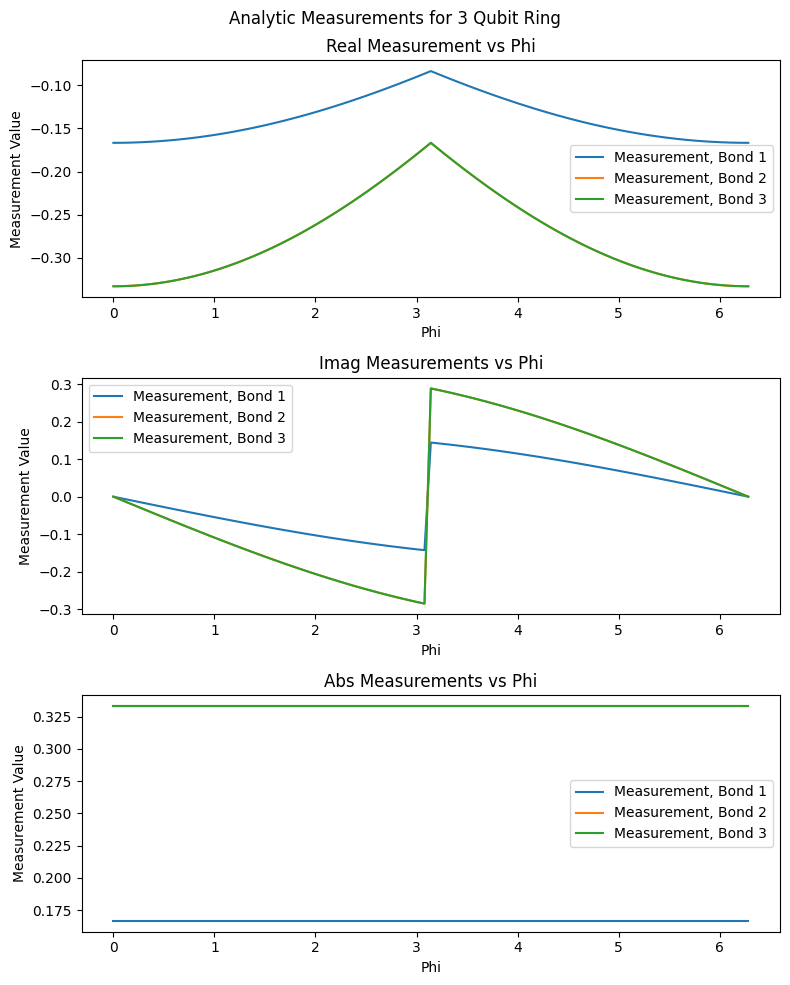

In [152]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

for i in range(num_qubits):
    axes[0].plot(phis, measurements_analytic[:,i].real, label=f'Measurement, Bond {i+1}')
    axes[1].plot(phis, measurements_analytic[:,i].imag, label=f'Measurement, Bond {i+1}')
    axes[2].plot(phis, np.abs(measurements_analytic[:,i]), label=f'Measurement, Bond {i+1}')

axes[0].set_xlabel('Phi')
axes[0].set_ylabel('Measurement Value')
axes[0].set_title('Real Measurement vs Phi')
axes[0].legend()

axes[1].set_xlabel('Phi')
axes[1].set_ylabel('Measurement Value')
axes[1].set_title('Imag Measurements vs Phi')
axes[1].legend()

axes[2].set_xlabel('Phi')
axes[2].set_ylabel('Measurement Value')
axes[2].set_title('Abs Measurements vs Phi')
axes[2].legend()

plt.suptitle(f'Analytic Measurements for {num_qubits} Qubit Ring')

plt.tight_layout()
plt.show()
